# NB03: Exploratory Data Analysis

In [35]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Analysis of data from all MSOAs in London

In [36]:
travel_df = pd.read_csv("data/processed/msoa_duration.csv")

In [37]:
travel_df.head()

,msoa11,duration_to_central,oslaua,borough
0,E02000001,13,E09000001,City of London
1,E02000002,72,E09000002,Barking and Dagenham
2,E02000003,75,E09000002,Barking and Dagenham
3,E02000004,72,E09000002,Barking and Dagenham
4,E02000005,72,E09000002,Barking and Dagenham


In [38]:
travel_df.describe()

,duration_to_central
count,983.000000
mean,55.138352
std,13.745771
min,13.000000
25%,46.000000
50%,55.000000
75%,65.000000
max,103.000000


In [39]:
print(f"{travel_df["duration_to_central"].isna().sum() / len(travel_df["duration_to_central"]) * 100}% of postcodes failed to provide a journey calculation")
print(f"That's {travel_df["duration_to_central"].isna().sum()} MSOAs that don't have data")
# An improvement from my first attempt, as I documented in NB01

0.0% of postcodes failed to provide a journey calculation
That's 0 MSOAs that don't have data


### Creating the MSOA map using Geopandas

In [40]:
# Load the shapefile with MSOA boundaries
msoa_gdf = gpd.read_file("data/raw/2011_MSOAs/MSOA_2011_London_gen_MHW.shp")

# Check the column names in both datasets
print("Shapefile columns:", msoa_gdf.columns.tolist())
print("CSV columns:", travel_df.columns.tolist())

Shapefile columns: ['MSOA11CD', 'MSOA11NM', 'LAD11CD', 'LAD11NM', 'RGN11CD', 'RGN11NM', 'USUALRES', 'HHOLDRES', 'COMESTRES', 'POPDEN', 'HHOLDS', 'AVHHOLDSZ', 'geometry']
CSV columns: ['msoa11', 'duration_to_central', 'oslaua', 'borough']


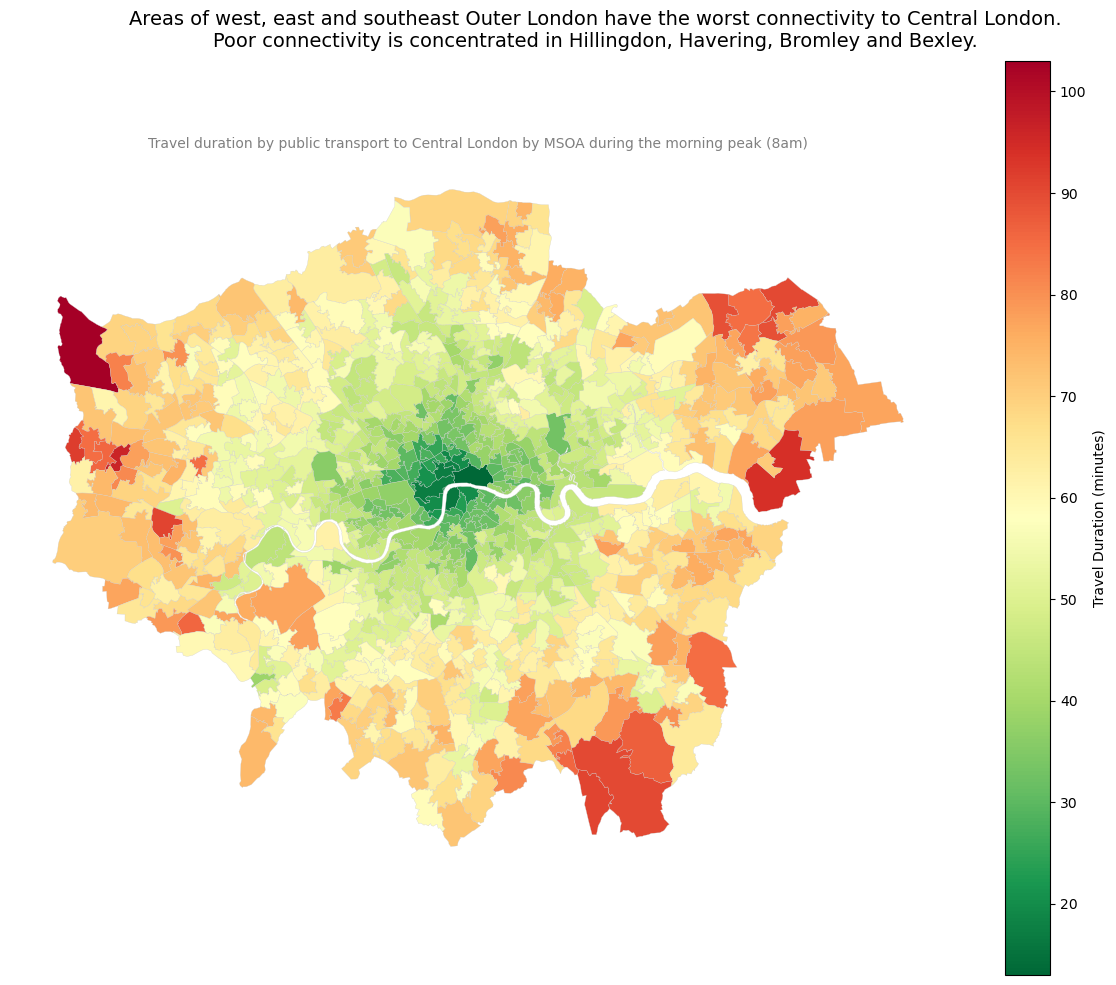

In [41]:
# Merge the datasets on the MSOA code column
# You'll need to adjust these column names to match your actual data
# Common MSOA code column names: 'MSOA11CD', 'msoa_code', 'MSOA_CODE'
merged = msoa_gdf.merge(
    travel_df,
    left_on="MSOA11CD",  # adjust to your shapefile's MSOA column
    right_on="msoa11",  # adjust to your CSV's MSOA column
    how="inner"
)

# Filter to London MSOAs only (if needed)
# London MSOA codes start with 'E02000001' through 'E02000983' approximately
# Or filter by name if your shapefile has a region column
london = merged[merged["MSOA11CD"].str.startswith("E020")]

# Create the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

london.plot(
    column="duration_to_central",  # adjust to your travel time column name
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Travel Duration (minutes)",
        "orientation": "vertical"
    },
    cmap="RdYlGn_r",  # red=long, green=short travel times
    edgecolor="0.8",
    linewidth=0.2
)

fig.suptitle("""Areas of west, east and southeast Outer London have the worst connectivity to Central London.
Poor connectivity is concentrated in Hillingdon, Havering, Bromley and Bexley.""", fontsize=14)
ax.set_title("Travel duration by public transport to Central London by MSOA during the morning peak (8am)", fontsize=10, color="gray")
ax.axis("off")

plt.tight_layout()
plt.savefig("figures/london_travel_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

**Personal Reflection Note:**

As soon as I saw the project brief for mini-project 2, a map along the lines of this is something I always had in mind as a goal of a visualisation I would like to create. I based this map quite heavily on TfL's own measures of transport connectivity, specifically their travel time mapping, which I found in their [official documentation when researching mini-project 2](https://content.tfl.gov.uk/connectivity-assessment-guide.pdf). TfL have other ways of measuring connectivity listed in the documentation, such as the Public Transport Access Level (PTAL) and Catchment Analysis, however the Travel Time Mapping to me seemed like the official TfL connectivity metric I could most closely replicate based on the Journey Planner API. Hence, this is why I chose this as one of my visualisations. I also chose this as my main visualisation because it provides a clear geographic overview of the transport connectivity in London, and allows readers to get an insight into how it varies across London better than a table would for example. From the visualisation, we can clearly see clusters of poor connectivity in Outer London, especially in the East (near Havering), West (around Hillingdon) and Southeast (near Bexley), and conversely quite good connectivity in Inner London (which is understandable) and Northern Outer London. The latter point was particularly interesting, and I wanted to research why this was the case, and [found](https://www.citymonitor.ai/analysis/why-are-there-so-few-tube-lines-south-london-2929/?cf-view) that a lot of North London is better connected via Tube specifically due to it historically having a larger population and having a better geology for tunnel boring for Tube lines (especially historically when technology was more limited than it is now). However, the same article does say that South London has good connection via traditional over-ground rail services, and of course buses are also an option, so I cannot say for certain that the reason Northern Outer London appears to have better connectivity is due to it having more Tube lines. My visualisation, by virtue of my data collection, only shows the connectivity during the morning peak hours, which while aligning with what TfL typically do, could limit my conclusion as night time connectivity may be different and therefore produce a different choropleth map. I did initially want to test the night time vs day time connectivity in London for each MSOA, but ultimately didn't as a limitation of TfL's Journey Planner API is that, for journeys where there's no night time connectivity, instead of outputting no night time journey (or an error), it suggests the next possible journey, which often times is when service starts at 4 or 5am, which isn't really helpful for assessing nighttime connectivity. It is for this reason, and how long the API call would have taken, that I stuck to only assessing the morning peak, even if that does mean that my analysis isn't as hollistic as it could have been due to this methodology.

In terms of actually constructing the choropleth map, I used the Geopandas library to do so. I believe we were meant to learn about Geopandas in the Week 9 lecture, however Jon said that he cut this to try and not confuse people right before mini-project 2 is due, but I spoke to Jon and he said it would be ok for me to still make the map. My first point of call was the [Geopandas documentation](https://geopandas.org/en/stable/), which I read about to see what Geopandas actually was and how it would be used. I learnt that it allows you to do operations in Python that normally would require special GIS software, and extends Pandas dataframes to allow for "spatial operations on geometric types". After learning this and feeling confident that I had discovered the right tool, I [downloaded the shapefiles for my map from the official London Database of the Greater London Authority](https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9/), and extracted the shapefiles for the 2011 MSOA boundaries in London, which is what the postcode directory uses. I then [asked Claude](https://claude.ai/share/72972924-1109-40e9-b3d1-40c34ad5a3ff) for help writing the code to make the choropleth map. At first, it didn't work, but when I debugged it with Claude I learnt that it wasn't enough to extract the .shp file, but instead that all the various shapefiles needed to be extracted to form the choropleth map. This is why I created the "2011_MSOAs" folder in my data/raw folder, as this is where the shapefiles are contained. After I did this, it worked and produced the choropleth map you see above! I also didn't use the plot_df tradition to make this choropleth map, which I hope is ok, as we haven't learnt it in class yet so I'm not sure if there is a specific DS105 way of using Geopandas. For my next project, if we do make something with a map and we haven't covered Geopandas in class yet, I will ensure I book an office hour or attend a drop-in session to see if there is a specific DS105 way of using Geopandas that I should be aware of, like we have the plot_df tradition for "ordinary" plots.

### Borough Analysis and Aggregations based on MSOA data

In this section of my EDA, I wanted to explore borough-level aggregations of travel times to see both how median travel times varied across boroughs, but also what the variance/difference in travel times was like within boroughs.

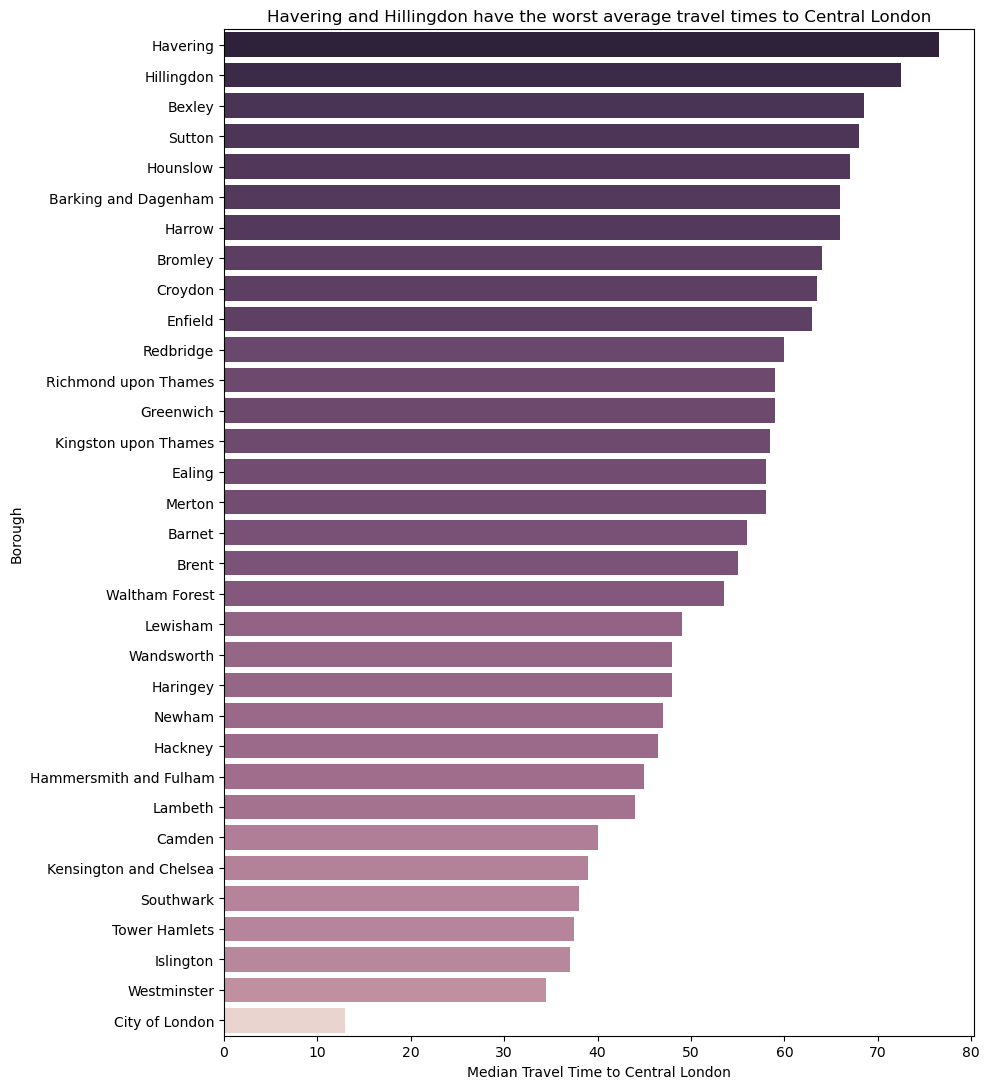

In [8]:
plot_df = pd.DataFrame(travel_df.groupby("borough")["duration_to_central"].median()).sort_values("duration_to_central", ascending=False).reset_index()
plt.figure(figsize=(10, 11))
sns.barplot(
    data=plot_df,
    x='duration_to_central',
    y='borough',
    hue='duration_to_central',
    legend=False
)
plt.title('Havering and Hillingdon have the worst average travel times to Central London')
plt.xlabel('Median Travel Time to Central London')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()

In [9]:
# Will use in later sections of NB03
top10worstconnected = list(plot_df["borough"][:10])
medianorder = list(plot_df["borough"])

**Personal Reflection Notes:**

The code I used to create the bar chart above is heavily inspired by the code we used to create the list of countries based on sanctioned entities from the Week 7 lab, because I found a "horizontally reoriented" (for lack of better description!) bar chart was the best here for displaying the 33 boroughs and their names, rather than a traditional bar chart. I know Jon said not to use box plots for averages in several of our lectures including the Week 9 lecture, which is why I would never use this as my final visualisation, but I did this to get a "flavour" of what the borough-level aggregated data looked like before diving into details below.

I also made the 2 lists above as a way of "connecting" my analysis from the MSOA-level aggregations to the deprivation analysis in the later section of my NB03. I created a list of the top 10 worst connected boroughs based on their median journey times, as well as the order they appear in, and this will be later used as the "hue" of my barcharts to deepen my analysis, and as a way of giving my boxplots and violin plots an order to make them look neater.

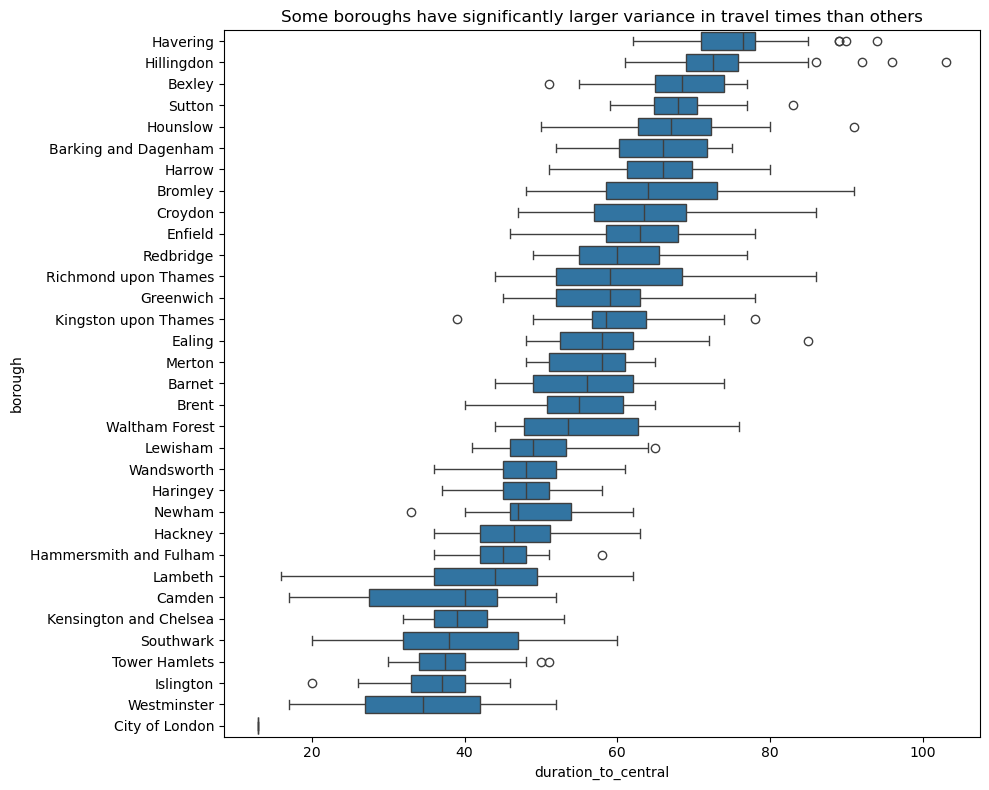

In [10]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=travel_df, x='duration_to_central', y='borough', order=medianorder)
plt.title('Some boroughs have significantly larger variance in travel times than others')
plt.tight_layout()
plt.show()

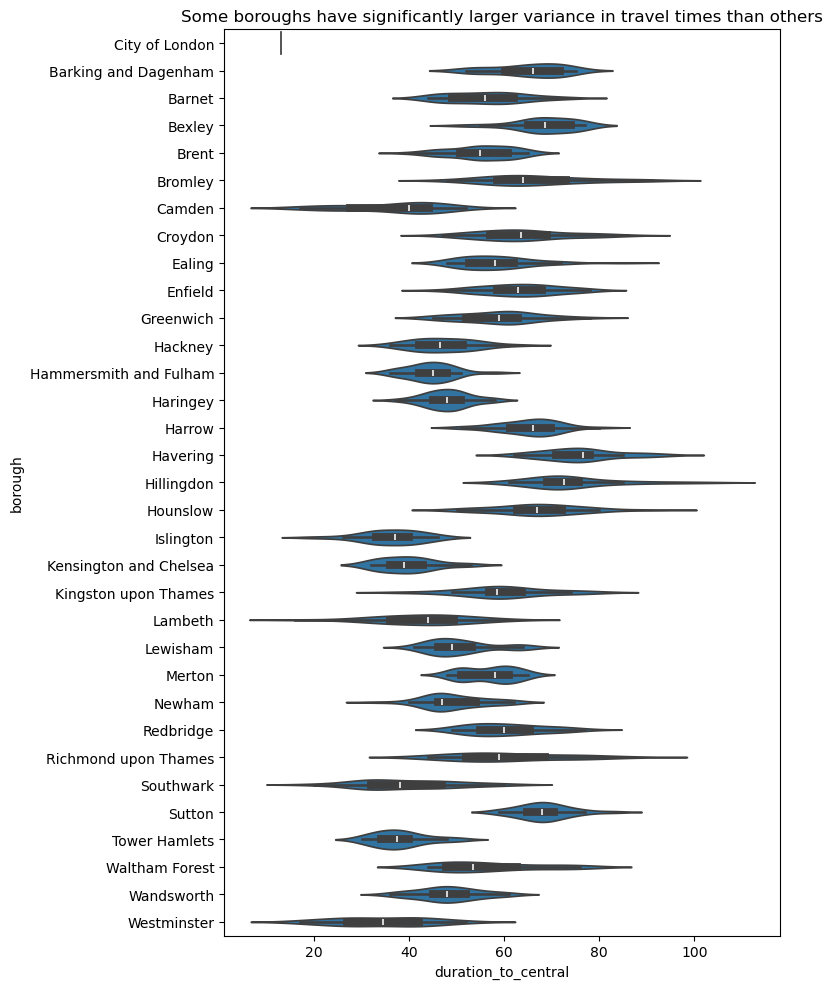

In [11]:
plt.figure(figsize=(8, 10))
sns.violinplot(data=travel_df, x='duration_to_central', y='borough')
plt.title('Some boroughs have significantly larger variance in travel times than others')
plt.tight_layout()
plt.show()

**Personal Reflection Notes:**

I used the [DS105 Claude Bot](https://claude.ai/share/12a954b7-f383-4950-aad1-9c1bbfd8e12c) to help with this code to create the box and violin plots. The DS105 Claude Bot said I didn't need the plot_df structure for these box plots, which is why it wasn't used, but again these aren't intended to be my final visualisations and are just a way of me seeing the differences in travel times within boroughs. I chose to use box plots and violin plots after our Week 9 lecture and especially our Week 9 lab and the task of seeing what visualisations were the best given a specific set of data.

These visualisations were quite insightful, and showed that most boroughs have quite significant variation in travel times between MSOAs in the same borough. The only strange exception was the City of London, which seemed to have no variation, but then I found that this was because of a limit in my methodology: the City of London has only 1 MSOA. It itself is an MSOA. However, I don't think this limits my analysis too much given that the City of London is in Central London, specifically the [Central Activities Zone](https://www.london.gov.uk/programmes-strategies/planning/implementing-london-plan/london-plan-guidance-and-spgs/central-activities-zone) used to designate the economic centre of London, therefore is in my view more of a "destination" for commuters rather than a "source". I do partially rectify this in my later analysis in this notebook, as my deprivation analysis takes 2 postcodes from the City of London, but ultimately (spoilers) it finds that the City of London has quite low variation in its travel times between deprived and non-deprived areas anyway, so the use of only 1 postcode for the City of London doesn't seem to be that big of an issue.

The variation in the travel times within boroughs is what my main takeaway from this visualisation was, and this is what prompted me to look at whether these differences in travel times could be because of differences in deprivation within boroughs. This then leads onto the next section of my EDA, which looks into the deprivation analysis based on the journey data for the most and least deprived areas in each borough that I collected.

## Deprivation Analysis - Most Deprived vs Least Deprived

In this section, I analyse differences in travel times between the most and least deprived areas in each borough to answer the question I was left with after my initial EDA in the previous section, which is: given the variations of travel times to Central London within boroughs, do the most deprived areas in each borough have worse connectivity to central London than the least deprived areas in each borough?

In [12]:
mostdeprived = pd.read_csv("data/processed/most_deprived_processed.csv")
leastdeprived = pd.read_csv("data/processed/least_deprived_processed.csv")

In [13]:
mostdeprived.describe()

,imd,lat,long,duration_to_central,total_walking,distance_to_lse,average_speed_kmh
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,2905.969697,51.506793,-0.109555,57.848485,20.545455,12.296638,12.149226
std,1554.874864,0.072635,0.159257,14.027030,6.195214,5.667075,3.553967
min,546.000000,51.353325,-0.394377,30.000000,9.000000,2.868134,5.736268
25%,2091.000000,51.459956,-0.207525,49.000000,17.000000,7.062952,9.417269
50%,2565.000000,51.515567,-0.106395,58.000000,20.000000,12.285998,11.798391
75%,3591.000000,51.553080,-0.021213,66.000000,23.000000,16.253609,14.530697
max,8678.000000,51.628319,0.213145,91.000000,37.000000,25.147021,17.876029


In [14]:
leastdeprived.describe()

,imd,lat,long,duration_to_central,total_walking,distance_to_lse,average_speed_kmh
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,29303.151515,51.505468,-0.118613,54.424242,21.424242,12.334933,12.918690
std,3759.135748,0.079920,0.153651,12.041673,6.265133,6.042438,4.620739
min,17580.000000,51.342521,-0.415139,28.000000,10.000000,1.994978,4.274952
25%,28095.000000,51.440866,-0.205128,48.000000,16.000000,7.776355,9.720444
50%,30161.000000,51.501994,-0.139967,54.000000,22.000000,12.488665,12.780579
75%,31858.000000,51.564725,0.004976,62.000000,25.000000,15.593052,15.090050
max,32563.000000,51.638473,0.248237,87.000000,35.000000,25.545694,22.876741


### Analysing differences in travel time between the most and least deprived areas in each borough

In [15]:
mostdeprived_cut = mostdeprived[["borough", "duration_to_central"]].reset_index().drop(["index"], axis=1)
mostdeprived_cut

,borough,duration_to_central
0,City of London,30
1,Barking and Dagenham,65
2,Barnet,49
3,Bexley,71
4,Brent,54
5,Bromley,66
6,Camden,49
7,Croydon,63
8,Ealing,62
9,Enfield,71


In [16]:
leastdeprived_cut = leastdeprived[["borough", "duration_to_central"]].reset_index().drop(["index"], axis=1)
leastdeprived_cut

,borough,duration_to_central
0,City of London,28
1,Barking and Dagenham,55
2,Barnet,58
3,Bexley,65
4,Brent,58
5,Bromley,56
6,Camden,43
7,Croydon,54
8,Ealing,53
9,Enfield,66


In [17]:
merged_deprivation = mostdeprived_cut.merge(leastdeprived_cut, on="borough", suffixes=('_most_deprived', '_least_deprived'))
merged_deprivation["difference"] = merged_deprivation["duration_to_central_most_deprived"] - merged_deprivation["duration_to_central_least_deprived"]
merged_deprivation

,borough,duration_to_central_most_deprived,duration_to_central_least_deprived,difference
0,City of London,30,28,2
1,Barking and Dagenham,65,55,10
2,Barnet,49,58,-9
3,Bexley,71,65,6
4,Brent,54,58,-4
5,Bromley,66,56,10
6,Camden,49,43,6
7,Croydon,63,54,9
8,Ealing,62,53,9
9,Enfield,71,66,5


In [18]:
merged_deprivation["difference"].describe()

count    33.000000
mean      3.424242
std       8.681987
min     -13.000000
25%      -3.000000
50%       5.000000
75%       9.000000
max      24.000000
Name: difference, dtype: float64

**Personal Reflection Note:**

In this section, I used pd.merge (as learnt in Week 7) and Pandas' vectorised operations to calculate the differences in journey times between the most deprived and least deprived areas in each borough, with the "difference" being a measure of "how much longer is a journey from the most deprived area to central London than the least deprived area to Central London" for each borough. I also used the df.describe() tool shown in the Week 9 lecture, and given to me in the feedback I got for mini-project 1, to see what the maximum, minimum and median differences between the most and least deprived areas were. When I first tried to merged the dataframes, it didn't work as I intended since the column names for "duration_to_central" were the same for both dataframes, which is when I [asked Claude](https://claude.ai/share/b3286fea-832e-48ef-b76e-8854e4bf7254) and as a result discovered the "add suffix" method, which I used and was able to then fix the issue.

In [19]:
plot_df = merged_deprivation[["borough", "difference"]].sort_values("difference", ascending=False)

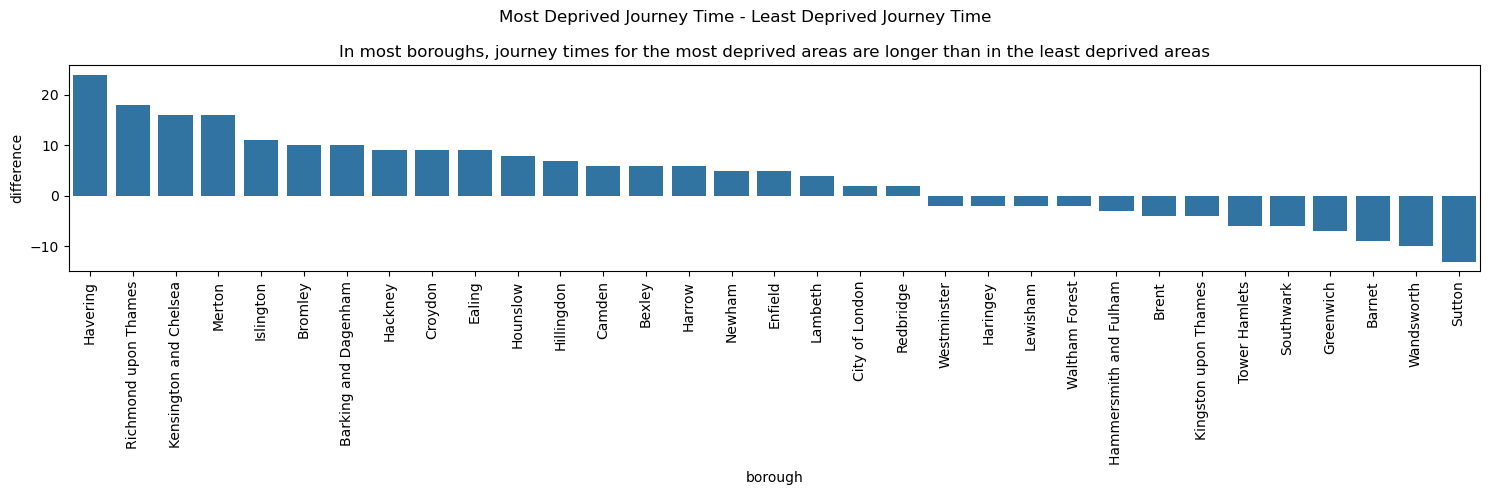

In [20]:
plt.figure(figsize=(15, 5))
sns.barplot(data=plot_df, x='borough', y='difference')
plt.title("In most boroughs, journey times for the most deprived areas are longer than in the least deprived areas")
plt.suptitle("Most Deprived Journey Time - Least Deprived Journey Time")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Personal Reflection:**

From this, I can see that, in most boroughs, the journey to central London takes longer from the most deprived area than the least deprived area. This is especially for Havering, which I identified in my first section of the EDA as one of the "problematic" boroughs with the worst connectivity to central London overall, so this seems like the issue of poor connectivity in Havering is compounded even further with differences in deprivation. However, contrary to what I thought, this trend isn't actually seen across all boroughs, with boroughs such as Sutton actually having the most deprived area have a lower travel time to central London than the least deprived area.

### Analysing Differences in Average Speed of Travel

In this section, rather than just using the pure "duration" measure of connectivity, I use the average speed calculations I created in NB02 based on **both** the duration and the distance each postcode is from LSE to see which are the boroughs where the most deprived area has a slower journey to central London than the least deprived area. A slower average journey speed could also indicate poor connectivity, as it shows that the duration of the journey was quite high for the distance of it.

#### Journey Speed (nominal)

In [21]:
mostdeprived_speed = mostdeprived[["borough", "average_speed_kmh"]].reset_index().drop(["index"], axis=1)
leastdeprived_speed = leastdeprived[["borough", "average_speed_kmh"]].reset_index().drop(["index"], axis=1)
merged_speed = mostdeprived_speed.merge(leastdeprived_speed, on="borough", suffixes=('_most_deprived', '_least_deprived'))
merged_speed["difference"] =  merged_speed["average_speed_kmh_least_deprived"] - merged_speed["average_speed_kmh_most_deprived"]
merged_speed

,borough,average_speed_kmh_most_deprived,average_speed_kmh_least_deprived,difference
0,City of London,5.736268,4.274952,-1.461317
1,Barking and Dagenham,14.390707,16.611093,2.220386
2,Barnet,11.337610,14.233789,2.896179
3,Bexley,17.876029,18.517148,0.641119
4,Brent,11.539398,15.049339,3.509940
5,Bromley,13.613791,21.335757,7.721966
6,Camden,6.316805,7.516213,1.199408
7,Croydon,13.300902,20.663694,7.362792
8,Ealing,14.334715,10.884787,-3.449929
9,Enfield,11.670055,12.665728,0.995673


In [22]:
merged_speed["difference"].describe()

count    33.000000
mean      0.769464
std       3.083569
min      -5.531540
25%      -1.461317
50%       0.641119
75%       2.488836
max       7.721966
Name: difference, dtype: float64

In [23]:
plot_df = merged_speed[["borough", "difference"]].sort_values("difference", ascending=False)
plot_df["top10worstconnected"] = plot_df["borough"].isin(top10worstconnected)

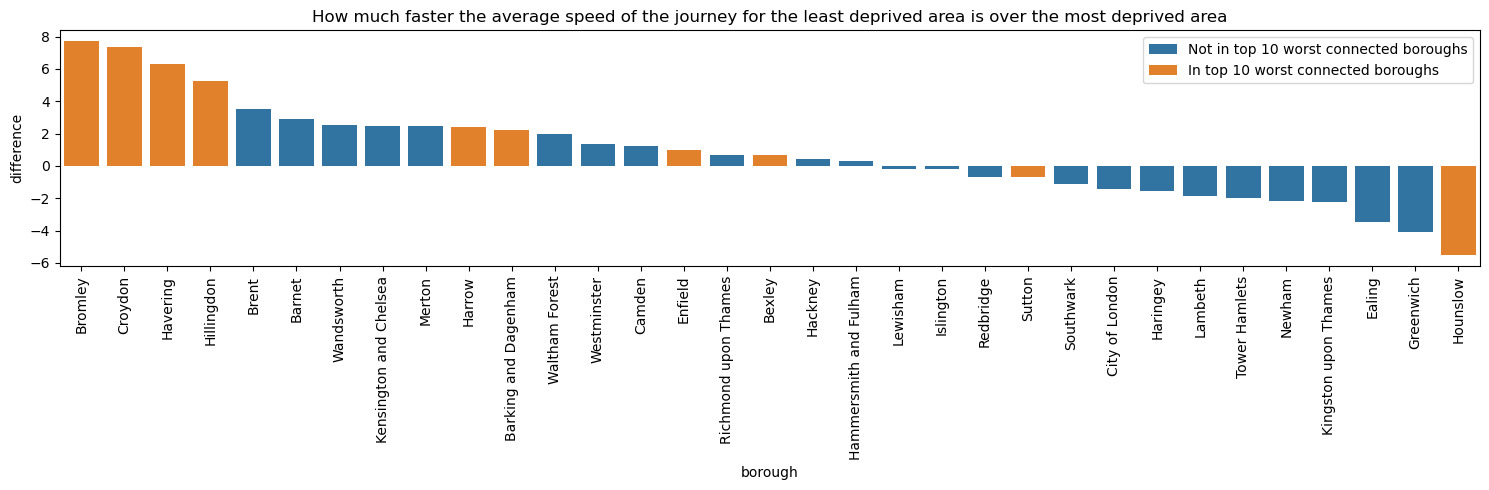

In [24]:
plt.figure(figsize=(15, 5))
sns.barplot(data=plot_df, x='borough', y='difference', hue="top10worstconnected")
plt.title("How much faster the average speed of the journey for the least deprived area is over the most deprived area")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Not in top 10 worst connected boroughs', 'In top 10 worst connected boroughs'], title='')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [25]:
# Took the boroughs with journey differences above the Q3 value to use in my plot
plot_df = plot_df[plot_df["difference"] > 2.488836]
plot_df

,borough,difference,top10worstconnected
5,Bromley,7.721966,True
7,Croydon,7.362792,True
15,Havering,6.296288,True
16,Hillingdon,5.242261,True
4,Brent,3.509940,False
2,Barnet,2.896179,False
31,Wandsworth,2.548837,False
19,Kensington and Chelsea,2.490409,False
23,Merton,2.488836,False


In [26]:
len(plot_df)

9

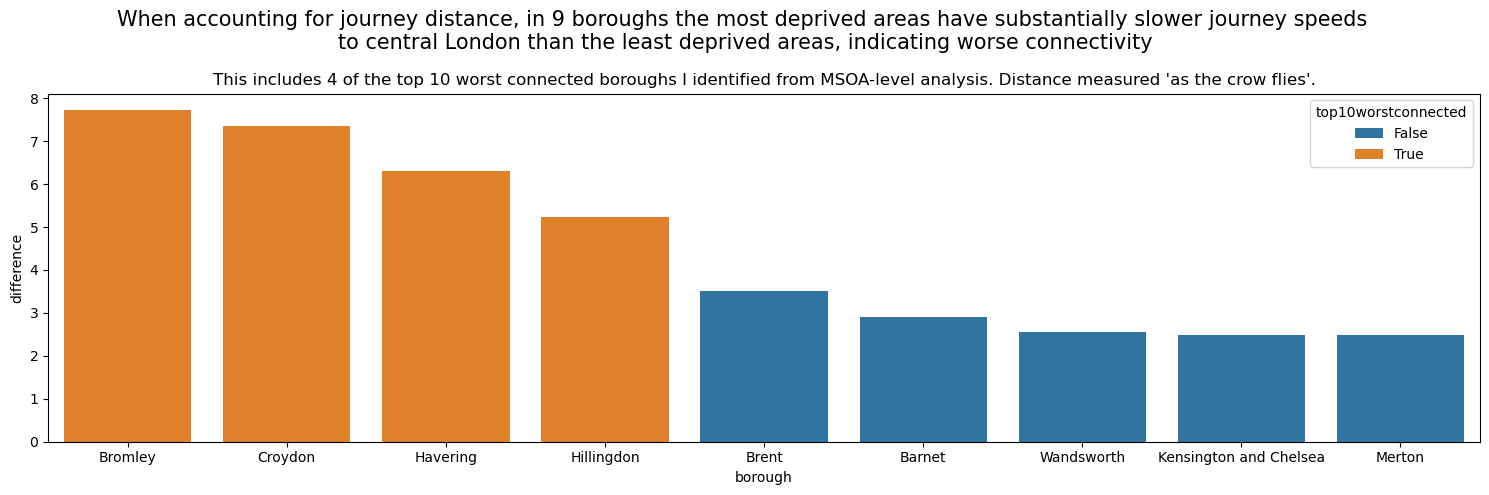

In [27]:
plt.figure(figsize=(15, 5))
sns.barplot(data=plot_df, x='borough', y='difference', hue="top10worstconnected")
plt.suptitle("""When accounting for journey distance, in 9 boroughs the most deprived areas have substantially slower journey speeds 
to central London than the least deprived areas, indicating worse connectivity""", fontsize=15)
plt.title("This includes 4 of the top 10 worst connected boroughs I identified from MSOA-level analysis. Distance measured 'as the crow flies'.", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Personal Reflection Notes:**

These visualisations and analysis have shown that, again just like in my analysis of differences in journey times, it wasn't the case that in all boroughs the average speed was worse in the most deprived areas vs the least deprived areas. A particular "pipeline" of analysis I found quite useful and insightful was, after creating my dataframe and initial bar chart showing all the boroughs of London, using df.describe() to find the statistical summary and specifically the interquartile range of the data. Then, I created another visualisation only including boroughs whose difference for speed between the most and least deprived areas was above Q75 to find the boroughs where the most deprived areas are at an especially large speed disadvantage. This showed me 9/33 of London's boroughs(+ the City of London) where the most deprived areas seem to have this speed disadvantage, of which 4 were boroughs I had identified in the top 10 worst connected in my analysis of MSOA-level travel duration. This is an interesting pattern in the data, and could perhaps suggest a fundamental issue in transport connectivity in these boroughs in particular, especially in deprived areas. However, of course this is just EDA and not a scientific or statistical analysis, therefore I cannot say this for certain.

#### Journey Speed - Percentage Difference

In [28]:
mostdeprived_speed = mostdeprived[["borough", "average_speed_kmh"]].reset_index().drop(["index"], axis=1)
leastdeprived_speed = leastdeprived[["borough", "average_speed_kmh"]].reset_index().drop(["index"], axis=1)
merged_speed = mostdeprived_speed.merge(leastdeprived_speed, on="borough", suffixes=('_most_deprived', '_least_deprived'))
merged_speed["difference%"] =  (merged_speed["average_speed_kmh_least_deprived"] - merged_speed["average_speed_kmh_most_deprived"])/merged_speed["average_speed_kmh_most_deprived"]*100
merged_speed["difference%"].describe()

count    33.000000
mean      6.806888
std      23.446179
min     -33.465478
25%     -13.083835
50%       4.548096
75%      22.974298
max      56.721647
Name: difference%, dtype: float64

In [29]:
plot_df = merged_speed[["borough", "difference%"]].sort_values("difference%", ascending=False)
plot_df["top10worstconnected"] = plot_df["borough"].isin(top10worstconnected)
plot_df = plot_df[plot_df["difference%"] > 22.974298]
plot_df

,borough,difference%,top10worstconnected
5,Bromley,56.721647,True
7,Croydon,55.355587,True
15,Havering,37.974158,True
19,Kensington and Chelsea,34.368376,False
16,Hillingdon,33.635464,True
4,Brent,30.417013,False
31,Wandsworth,27.770274,False
2,Barnet,25.544877,False


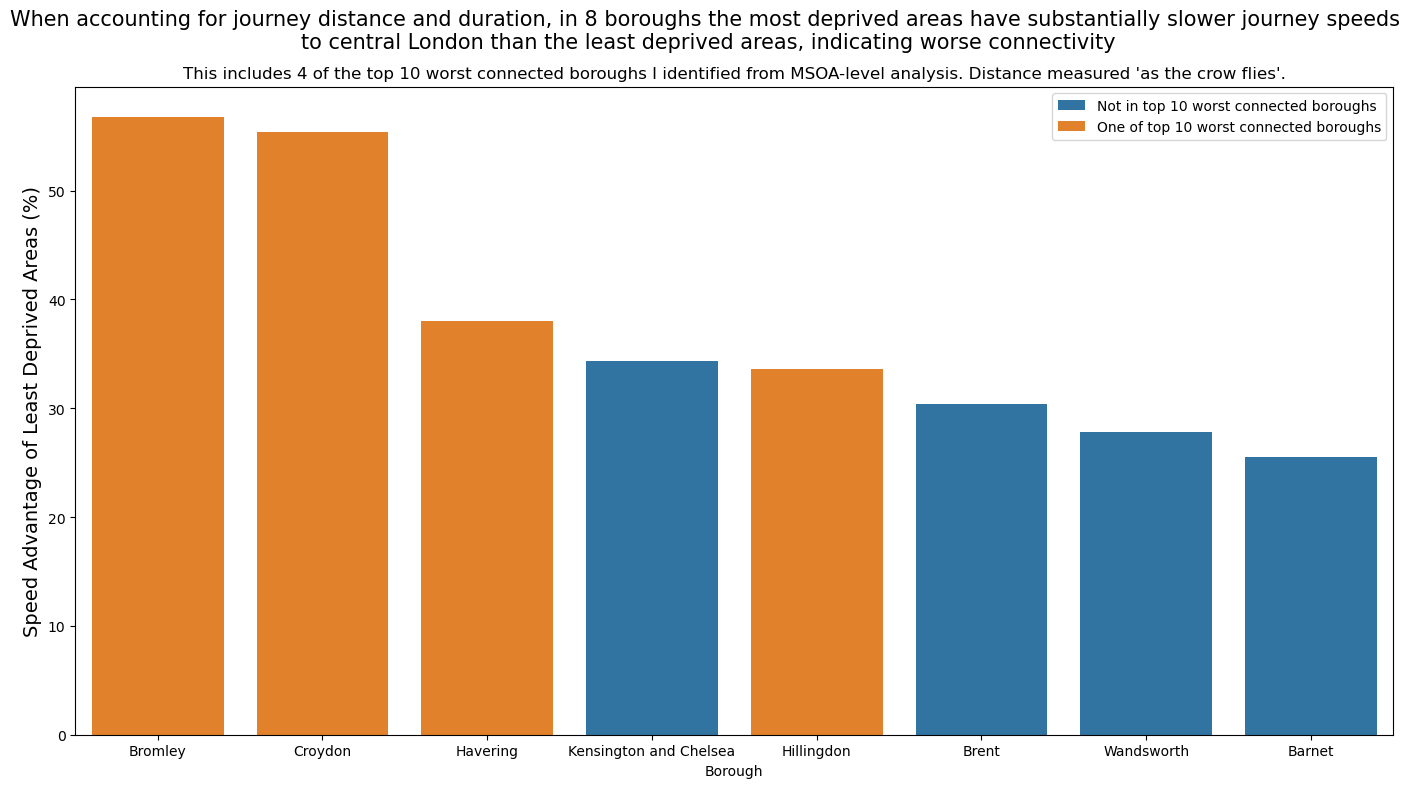

In [30]:
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x='borough', y='difference%', hue="top10worstconnected")
plt.suptitle("""When accounting for journey distance and duration, in 8 boroughs the most deprived areas have substantially slower journey speeds 
to central London than the least deprived areas, indicating worse connectivity""", fontsize=15)
plt.title("This includes 4 of the top 10 worst connected boroughs I identified from MSOA-level analysis. Distance measured 'as the crow flies'.", fontsize=12)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Not in top 10 worst connected boroughs', 'One of top 10 worst connected boroughs'], title='')
plt.xlabel('Borough')
plt.ylabel('Speed Advantage of Least Deprived Areas (%)', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/speedchart.png")
plt.show()

**Personal Reflection Note:**

This visualisation is again quite interesting, and shows the 8 "outlier" boroughs where the speed difference in percentage terms was higher than Q75 so outside the interquartile range. The same boroughs from the "nominal" speed analysis show up again, (nearly) in the same order locking out 4 of the top 5 positions.

I decided to use this visualisation as my second figure after a lot of thinking about what best would complement the chloropeth map I used as my first visualisation, and some advice from the drop-in session with Jon. I chose this specific visualisation because it provides a slightly different measure of connectivity to the pure duration my choropeth, and ultimately TfL's Time Mapping method, does because it takes into account the distance each location is from Central London. This is important because, if we take 2 hypothetical locations that both take an hour to get to central London but one is 5km away whereas the other is 20km, one could argue that the further away location has better "connectivity" given its faster average speed for the journey. This does differ somewhat from the official TfL documentation I based my chloropleth map on, however there is precedent for TfL and the Greater London Authority using the average speed of public transport as a quasi-measure of connectivity. For example, a salient discussion in London at the time of writing is the decline in average bus journey speeds, as seen in [this Greater London Assembly investigation started on December 1st 2025](https://www.london.gov.uk/who-we-are/what-london-assembly-does/london-assembly-work/london-assembly-current-investigations/bus-journey-times), therefore I would argue that there is precedent to look at the average speed of a journey as a way of measuring transport connectivity.

This visualisation shows, for each borough, what percentage faster the journey from the least deprived area to central London is compared to the journey from the most deprived area to central London. I chose this rather than the "nominal" differences in km/h because the average speeds were quite slow in general, so a difference of 7.7km/h (which was the maximum) may not sound like a lot to the reader, but in reality that represents an over 50% difference between journey speeds. Therefore, I argue that the percentage differences help represent the true differences in speed more accurately. I had initially made the visualisation with all the boroughs included, but then I cut it down to only include the boroughs where the percentage difference was above Q75 (so above the interquartile range). I also chose to include a "hue" for whether the borough was in the top 10 worst-connected boroughs based on their median travel time when I did my MSOA-level analysis, as a nice way to hopefully tie together my 2 visualisations and analyses.

This visualisation could, when complemented with my choropleth map, show policymakers that the boroughs of Bromley, Croydon, Havering and Hillingdon in particular should have special attention paid to them for transport improvements, especially in the most deprived areas. This is because, not only are these boroughs identified as those with some of the worst connectivity from the choropleth map (and analysis based on the MSOA-level travel times I collected), but also these are the boroughs where the difference in average journey speed between the most deprived and least deprived areas is greatest (in the direction of disfavouring the most deprived area).

Of course, what my analysis doesn't show is **why** the connectivity is poorer in these areas. It could be because they don't have a direct Tube line that reaches them, so may rely on buses that are slower and impacted more by traffic. It could also be because the journey they have to take is less direct, involving multiple changes or taking a route that "meanders" more rather than being a direct connection. Ultimately, the question of **why** isn't one I cannot explain with this EDA, so I shouldn't attempt to to avoid conjecture. However, I hope this EDA can provoke further analysis specifically in these boroughs identified as having the worst connectivity to find out why that is the case. My analysis of speeds (and durations) is also limited to the data I collected for the morning peak. This could be another potential limitation because perhaps some areas (including deprived areas) have good connectivity in the morning peak time, but then that connection disappears in off-peak hours, which could indicate poor connectivity. Therefore, perhaps my analysis could be understating the differences in connectivity between more and less deprived areas within boroughs, because maybe the connectivity gap isn't that bad in the peak hours, but actually gets worse in off-peak hours. Again, this would require further analysis that this report sadly does not cover, but I thought it would be worth mentioning to acknowledge this limitation of my analysis for transparency.

### Walking Duration Analysis

In NB01, I also collected the total walking durations for the journeys for the most deprived and least deprived areas of each borough, so in this section I will analyse those too, using a lot of the methods I have already discussed and refined in previous sections of this notebook.

In [31]:
mostdeprived_walk = mostdeprived[["borough", "total_walking"]].reset_index().drop(["index"], axis=1)
leastdeprived_walk = leastdeprived[["borough", "total_walking"]].reset_index().drop(["index"], axis=1)
merged_walk = mostdeprived_walk.merge(leastdeprived_walk, on="borough", suffixes=('_most_deprived', '_least_deprived'))
merged_walk["difference"] = merged_walk["total_walking_most_deprived"] - merged_walk["total_walking_least_deprived"]
merged_walk

,borough,total_walking_most_deprived,total_walking_least_deprived,difference
0,City of London,20,10,10
1,Barking and Dagenham,32,22,10
2,Barnet,23,23,0
3,Bexley,21,14,7
4,Brent,26,27,-1
5,Bromley,17,13,4
6,Camden,33,25,8
7,Croydon,20,15,5
8,Ealing,17,17,0
9,Enfield,37,35,2


In [32]:
merged_walk["top10worstconnected"] = merged_walk["borough"].isin(top10worstconnected)
plot_df = merged_walk[["borough", "difference", "top10worstconnected"]].sort_values("difference", ascending=False)

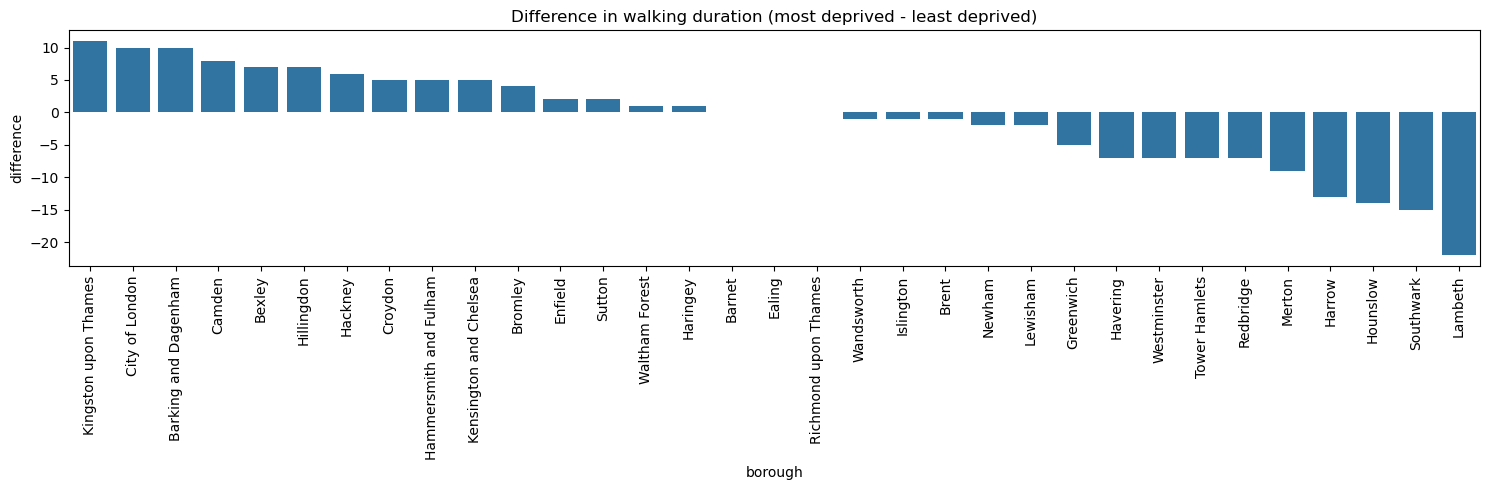

In [33]:
plt.figure(figsize=(15, 5))
sns.barplot(data=plot_df, x='borough', y='difference')
plt.title("Difference in walking duration (most deprived - least deprived)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Personal Reflection Note:**

I also decided to analyse the walking durations I had collected during my NB01 Data Collection to see if there was a meaningful difference between the total walking durations for the most deprived and least deprived areas in each borough. My thought process was that perhaps the most deprived areas won't have bus/train/tube stations close to them, so may have journeys that involve more walking than areas that are less deprived, who may have transport stations closer to them. However, the walking data didn't really produce clear insights. There are outliers such as Lambeth and Southwark (where contrary to my hypothesis, the least deprived areas have more walking in their journey) which could be interesting to explore, but ultimately I decided not to use this in my visualisations as I thought the aforementioned "average speed" metrics produced a more interesting insight. Furthermore, this could also be due to the methodology of the data collection I did for the deprivation comparisons, as I picked 1 postcode for the most deprived LSOA in each borough for a total of 33 "most deprived" postcodes and 33 "least deprived" postcodes. It could be that the postcode that I picked at random happened to be one that had a long walking time to get to LSE for whatever reason purely down to random change. This is why I'd argue that a better measure of transport accessibility that incorporates walking into its "score" is TfL's own [Public Transport Access Level](https://content.tfl.gov.uk/connectivity-assessment-guide.pdf) (PTAL) measure, which is accessible via their online [WebCAT tool](https://tfl.gov.uk/info-for/urban-planning-and-construction/planning-applications/planning-with-webcat) rather than the Journey Planner API. I found this earlier when I was researching for my methodology.